# 📘 Lasso & Elastic Net Regression — Complete Study Notes

---

## 📑 Table of Contents

1. [Recap: OLS & The Overfitting Problem](#1.-Recap:-OLS-&-The-Overfitting-Problem)
2. [What is Regularization?](#2.-What-is-Regularization?)
3. [Ridge vs Lasso — L2 vs L1 Norms](#3.-Ridge-vs-Lasso-—-L2-vs-L1-Norms)
4. [Lasso Regression (L1 Regularization)](#4.-Lasso-Regression-(L1-Regularization))
5. [Mathematical Derivation of Lasso](#5.-Mathematical-Derivation-of-Lasso)
6. [Why Lasso Creates Sparsity ⭐](#6.-Why-Lasso-Creates-Sparsity-⭐)
7. [How Alpha (λ) Affects Coefficients](#7.-How-Alpha-(λ)-Affects-Coefficients)
8. [Impact on Bias and Variance](#8.-Impact-on-Bias-and-Variance)
9. [Lasso — Code Implementation (sklearn)](#9.-Lasso-—-Code-Implementation)
10. [Elastic Net Regression](#10.-Elastic-Net-Regression)
11. [Ridge vs Lasso vs Elastic Net — Comparison](#11.-Ridge-vs-Lasso-vs-Elastic-Net-—-Comparison)
12. [Important Questions for Revision](#12.-Important-Questions-for-Revision)
13. [Quick Revision Cheat Sheet](#13.-Quick-Revision-Cheat-Sheet)

---
## 1. Recap: OLS & The Overfitting Problem

### Simple Linear Regression (1 feature)

$$\hat{y} = mx + b$$

where:
- $m$ = slope (coefficient)
- $b$ = intercept = $\bar{y} - m\bar{x}$

The slope in simple linear regression (OLS) is:

$$\boxed{m_{\text{OLS}} = \frac{\displaystyle\sum_{i=1}^{n}(y_i - \bar{y})(x_i - \bar{x})}{\displaystyle\sum_{i=1}^{n}(x_i - \bar{x})^2}}$$

### The Overfitting Problem

| Concept | Description |
|---------|-------------|
| **Underfitting** | Model is too simple (high bias, low variance). Example: fitting a straight line to quadratic data. |
| **Good fit** | Model captures the true pattern without memorizing noise. |
| **Overfitting** | Model is too complex (low bias, high variance). Example: fitting a high-degree polynomial to simple data. |

> **Key Insight:** Polynomial degree ↑ → complexity ↑ → overfitting risk ↑

**Regularization** is used to **prevent overfitting** by adding a penalty term to the loss function.

---
## 2. What is Regularization?

Regularization adds a **penalty** to the loss function to discourage large coefficient values.

$$\mathcal{L}_{\text{regularized}} = \underbrace{\text{Loss}(\text{data})}_{\text{How well model fits}} + \underbrace{\lambda \cdot \text{Penalty}(\text{coefficients})}_{\text{Keeps model simple}}$$

where:
- $\lambda$ (alpha) controls the **strength** of the penalty
- Higher $\lambda$ → more penalty → simpler model → **higher bias, lower variance**
- Lower $\lambda$ → less penalty → complex model → **lower bias, higher variance**

> ⚠️ **If $\lambda = 0$:** regularized regression becomes **normal linear regression** (no penalty at all).

---
## 3. Ridge vs Lasso — L2 vs L1 Norms

### L2 Norm → Ridge Regression

$$\|w\|_2^2 = w_1^2 + w_2^2 + w_3^2 + \cdots + w_n^2$$

**Ridge loss function:**

$$\mathcal{L}_{\text{Ridge}} = \sum_{i=1}^{n}(y_i - \hat{y}_i)^2 + \lambda(w_1^2 + w_2^2 + \cdots + w_n^2)$$

### L1 Norm → Lasso Regression

$$\|w\|_1 = |w_1| + |w_2| + |w_3| + \cdots + |w_n|$$

**Lasso loss function:**

$$\mathcal{L}_{\text{Lasso}} = \sum_{i=1}^{n}(y_i - \hat{y}_i)^2 + \lambda(|w_1| + |w_2| + \cdots + |w_n|)$$

### Key Difference at a Glance

| Property | Ridge (L2) | Lasso (L1) |
|----------|-----------|------------|
| Penalty term | $\lambda \sum w_j^2$ | $\lambda \sum |w_j|$ |
| Coefficients → 0? | Tends toward 0 but **never exactly** 0 | **Can be exactly 0** |
| Feature selection? | ❌ No | ✅ Yes |
| Best when | Many small/medium features | Few features are truly important |

---
## 4. Lasso Regression (L1 Regularization)

### Definition

**LASSO** = **L**east **A**bsolute **S**hrinkage and **S**election **O**perator

### Loss Function

$$\boxed{\mathcal{L}_{\text{Lasso}} = \underbrace{\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}_{\text{MSE}} + \underbrace{\lambda \sum_{j=1}^{p} |w_j|}_{\text{L1 penalty}}}$$

### Three Super-Powers of Lasso

| # | Power | Why it matters |
|---|-------|----------------|
| 1 | **Shrinks coefficients** | Reduces overfitting |
| 2 | **Drives coefficients to exactly zero** | Automatic **feature selection** |
| 3 | **Reduces dimensionality** | Fewer non-zero features = simpler model |

> 💡 **Remember:** Higher coefficients are shrunk more aggressively by Lasso!

---
## 5. Mathematical Derivation of Lasso

### Step 1 — Starting Point (Simple LR with 1 feature)

$$\hat{y} = mx + b, \quad b = \bar{y} - m\bar{x}$$

The Lasso loss function for simple linear regression:

$$\mathcal{L} = \sum_{i=1}^{n}(y_i - \hat{y}_i)^2 + \lambda |m|$$

Substituting $\hat{y}_i = mx_i + \bar{y} - m\bar{x}$:

$$\mathcal{L} = \sum_{i=1}^{n}(y_i - mx_i - \bar{y} + m\bar{x})^2 + \lambda |m|$$

### Step 2 — Taking the Derivative w.r.t. $m$

$$\frac{d\mathcal{L}}{dm} = 2\sum_{i=1}^{n} (y_i - mx_i - \bar{y} + m\bar{x}) \cdot (-x_i + \bar{x}) + \lambda \cdot \frac{d|m|}{dm}$$

> **The derivative of $|m|$ depends on the sign of $m$:**
>
> $$\frac{d|m|}{dm} = \begin{cases} +1 & \text{if } m > 0 \\ -1 & \text{if } m < 0 \\ \text{undefined} & \text{if } m = 0 \end{cases}$$
>
> (We use sub-gradient = 0 when $m = 0$, for making the math easy)

### Step 3 — Setting $\frac{d\mathcal{L}}{dm} = 0$ and Solving

Setting the derivative to zero:

$$2\sum_{i=1}^{n}\left[(y_i - \bar{y}) - m(x_i - \bar{x})\right](-x_i + \bar{x}) + 2\lambda \cdot \text{sign}(m) = 0$$

Expanding:

$$-\sum(y_i - \bar{y})(x_i - \bar{x}) + m\sum(x_i - \bar{x})^2 + \lambda \cdot \text{sign}(m) = 0$$

Solving for $m$:

$$m\sum(x_i - \bar{x})^2 = \sum(y_i - \bar{y})(x_i - \bar{x}) - \lambda \cdot \text{sign}(m)$$

### Step 4 — Final Formula: Three Cases

$$\boxed{m = \begin{cases} \dfrac{\sum(y_i - \bar{y})(x_i - \bar{x}) - \lambda}{\sum(x_i - \bar{x})^2} & \text{if } m > 0 \\[12pt] \dfrac{\sum(y_i - \bar{y})(x_i - \bar{x})}{\sum(x_i - \bar{x})^2} & \text{if } m = 0 \\[12pt] \dfrac{\sum(y_i - \bar{y})(x_i - \bar{x}) + \lambda}{\sum(x_i - \bar{x})^2} & \text{if } m < 0 \end{cases}}$$

---

**Compare with Ridge Regression** (for reference):

$$m_{\text{Ridge}} = \frac{\sum(y_i - \bar{y})(x_i - \bar{x})}{\sum(x_i - \bar{x})^2 + \lambda}$$

> 🔑 In **Ridge**, $\lambda$ appears in the **denominator** → $m$ tends to 0 but **never reaches** 0.
>
> 🔑 In **Lasso**, $\lambda$ appears in the **numerator** → $m$ **can become exactly** 0!

---
## 6. Why Lasso Creates Sparsity ⭐

This is one of the **most important** concepts — and a guaranteed exam question!

### The Key Insight

| Regression | Where does $\lambda$ appear? | Can $m = 0$? |
|------------|------------------------------|-------------|
| **Ridge** | **Denominator**: $\sum(x_i-\bar{x})^2 + \lambda$ | ❌ No — denominator just grows, $m \to 0$ but never $= 0$ |
| **Lasso** | **Numerator**: $\sum(y_i-\bar{y})(x_i-\bar{x}) - \lambda$ | ✅ Yes! — if $\lambda \geq$ numerator, $m$ becomes **exactly** 0 |

### Numerical Example

Let $\sum(y_i - \bar{y})(x_i - \bar{x}) = 100$ and $\sum(x_i - \bar{x})^2 = 50$

Using the Lasso formula for $m > 0$:  $m = \dfrac{100 - \lambda}{50}$

| $\lambda$ | Calculation | $m$ | Status |
|---|---|---|---|
| 0 | $(100-0)/50$ | **2.0** | Same as OLS |
| 10 | $(100-10)/50$ | **1.8** | Shrunk |
| 50 | $(100-50)/50$ | **1.0** | Shrunk more |
| 100 | $(100-100)/50$ | **0.0** | 🎯 **Exactly zero!** |
| 150 | $(100-150)/50$ | -1.0 → **contradiction** ($m>0$ assumed) | $m$ must be **0** |

> When $\lambda = 100$, the numerator becomes $0$, so $m = 0$.
>
> When $\lambda > 100$, the $m>0$ formula gives a negative value — **contradiction!**
> The $m<0$ formula gives: $m = (100+150)/50 = 5$ — also a contradiction (positive but we assumed $m<0$).
>
> So $m$ **must** be $0$. The coefficient is **eliminated**!

### In Ridge (for comparison)

Using $m_{\text{Ridge}} = \dfrac{100}{50 + \lambda}$

| $\lambda$ | $m_{\text{Ridge}}$ |
|---|---|
| 0 | 2.0 |
| 50 | 1.0 |
| 100 | 0.67 |
| 1000 | 0.095 |
| $\infty$ | → 0 but **never exactly 0** |

> The numerator is always $100$ — it **never** becomes $0$. So Ridge can never zero out a coefficient.

### 🧠 One-line Summary

> **In Lasso, $\lambda$ subtracts from the numerator → numerator can become 0 → coefficient = 0 → SPARSITY!**
>
> **In Ridge, $\lambda$ adds to the denominator → numerator is always non-zero → coefficient ≠ 0 → NO SPARSITY!**

---
## 7. How Alpha (λ) Affects Coefficients

Let's see this in action using the **Diabetes Dataset** (10 features).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Lasso
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load data
data = load_diabetes()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['TARGET'] = data.target
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,TARGET
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [3]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    data.data, data.target, test_size=0.2, random_state=2
)

### 7.1 Coefficients at Different Alpha Values

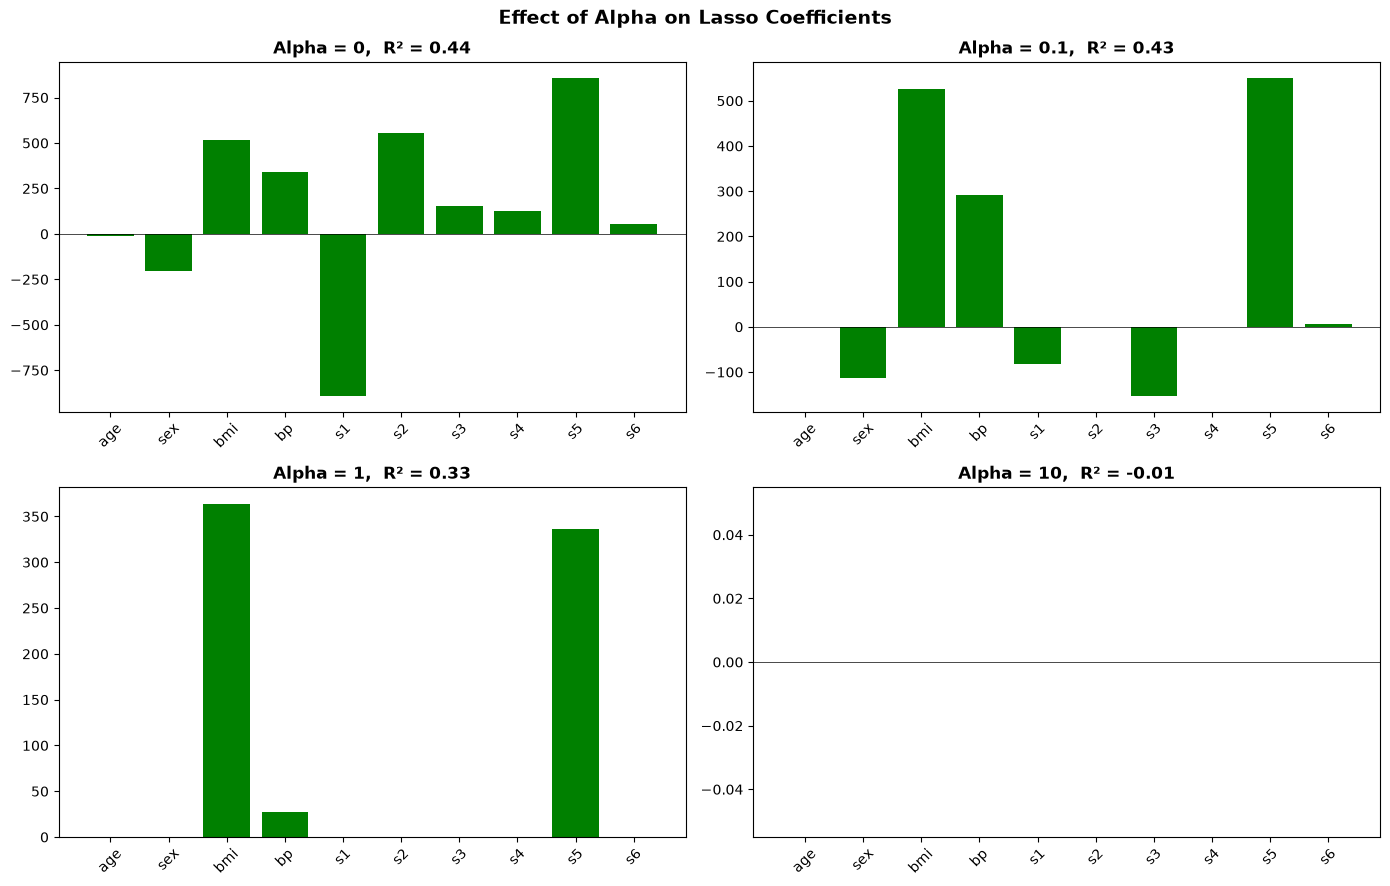

In [4]:
# Fit Lasso at different alpha values
coefs = []
r2_scores = []

for alpha in [0, 0.1, 1, 10]:
    reg = Lasso(alpha=alpha)
    reg.fit(X_train, y_train)
    coefs.append(reg.coef_.tolist())
    y_pred = reg.predict(X_test)
    r2_scores.append(r2_score(y_test, y_pred))

# Visualize
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for idx, (ax, alpha, coef, r2) in enumerate(zip(axes.flat, [0, 0.1, 1, 10], coefs, r2_scores)):
    colors = ['green' if c != 0 else 'red' for c in coef]
    ax.bar(data.feature_names, coef, color=colors)
    ax.set_title(f'Alpha = {alpha},  R² = {round(r2, 2)}', fontsize=12, fontweight='bold')
    ax.axhline(y=0, color='black', linewidth=0.5)
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Effect of Alpha on Lasso Coefficients', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Observations:**
- At $\alpha=0$: all 10 coefficients are non-zero (same as OLS)
- At $\alpha=0.1$: some small coefficients (e.g., `age`, `s2`, `s4`) shrink to 0
- At $\alpha=1$: most coefficients = 0; only `bmi` and `s5` survive
- At $\alpha=10$: **ALL coefficients = 0** — model just predicts the mean!

### 7.2 Coefficient Path — Higher Coefficients Are Affected More

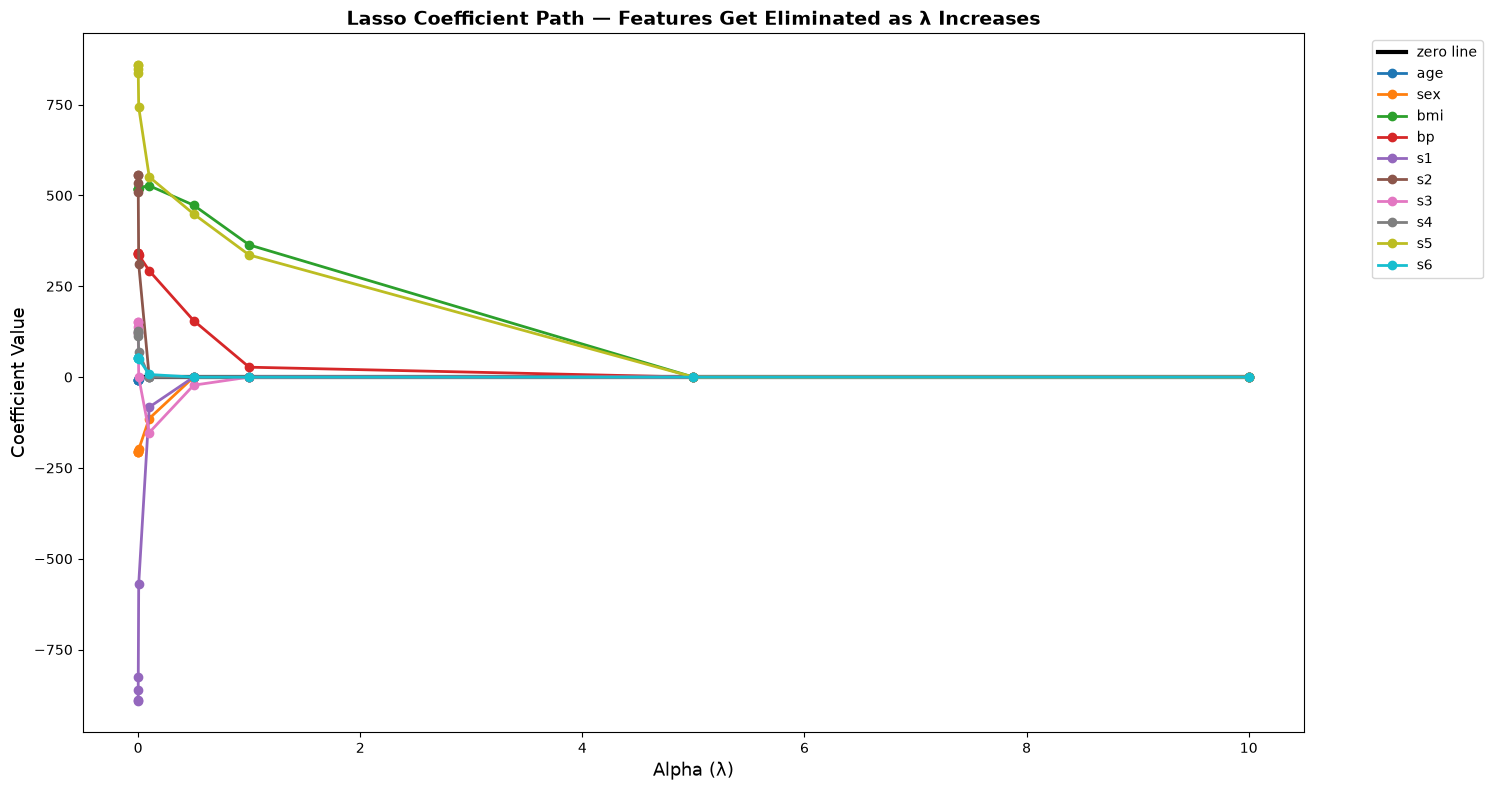

In [5]:
# Coefficient path across many alpha values
alphas = [0, 0.0001, 0.0005, 0.001, 0.005, 0.1, 0.5, 1, 5, 10]
coefs = []

for alpha in alphas:
    reg = Lasso(alpha=alpha)
    reg.fit(X_train, y_train)
    coefs.append(reg.coef_.tolist())

# Plot coefficient paths
coef_array = np.array(coefs).T
plt.figure(figsize=(15, 8))
plt.plot(alphas, np.zeros(len(alphas)), color='black', linewidth=3, label='zero line')
for i in range(coef_array.shape[0]):
    plt.plot(alphas, coef_array[i], 'o-', label=data.feature_names[i], linewidth=2)
plt.xlabel('Alpha (λ)', fontsize=13)
plt.ylabel('Coefficient Value', fontsize=13)
plt.title('Lasso Coefficient Path — Features Get Eliminated as λ Increases', fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

> 🏆 **Think of it like a survival game:** As $\lambda$ increases, features get eliminated one by one.
> The last ones standing (`bmi`, `s5`) are the **most important features!**

### 7.3 Coefficient Table Across Alpha Values

In [6]:
# Detailed coefficient table
alphas_table = [0, 0.0001, 0.001, 0.01, 0.1, 1, 10, 100]
coefs_table = []

for alpha in alphas_table:
    reg = Lasso(alpha=alpha)
    reg.fit(X_train, y_train)
    coefs_table.append(reg.coef_.tolist())

coef_df = pd.DataFrame(coefs_table, columns=data.feature_names)
coef_df.index = alphas_table
coef_df.index.name = 'alpha'
coef_df.round(2)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
alpha,,,,,,,,,,
0.0000,-9.16,-205.41,516.78,340.60,-890.75,557.46,151.76,126.11,859.35,52.42
0.0001,-9.07,-205.33,516.79,340.53,-888.66,555.96,150.59,125.45,858.65,52.38
0.0010,-8.26,-204.21,517.65,339.74,-826.66,508.62,120.91,113.92,836.32,52.01
0.0100,-1.36,-192.94,526.36,332.64,-430.23,191.30,-44.03,68.99,688.40,47.94
0.1000,0.00,-113.97,526.74,292.63,-82.69,-0.00,-152.69,0.00,551.08,7.17
1.0000,0.00,0.00,363.89,27.27,0.00,0.00,-0.00,0.00,336.14,0.00
10.0000,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
100.0000,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


---
## 8. Impact on Bias and Variance

### The Bias-Variance Tradeoff

$$\text{Total Error} = \text{Bias}^2 + \text{Variance} + \text{Irreducible Error}$$

| $\lambda$ | Overfitting | Bias | Variance |
|---|---|---|---|
| **Small** ($\to 0$) | ↑ More overfitting | ↓ Low bias | ↑ High variance |
| **Large** ($\to \infty$) | ↓ Less overfitting | ↑ High bias | ↓ Low variance |

> 🎯 **We choose $\lambda$ at the sweet spot** where total error (bias² + variance) is minimized.

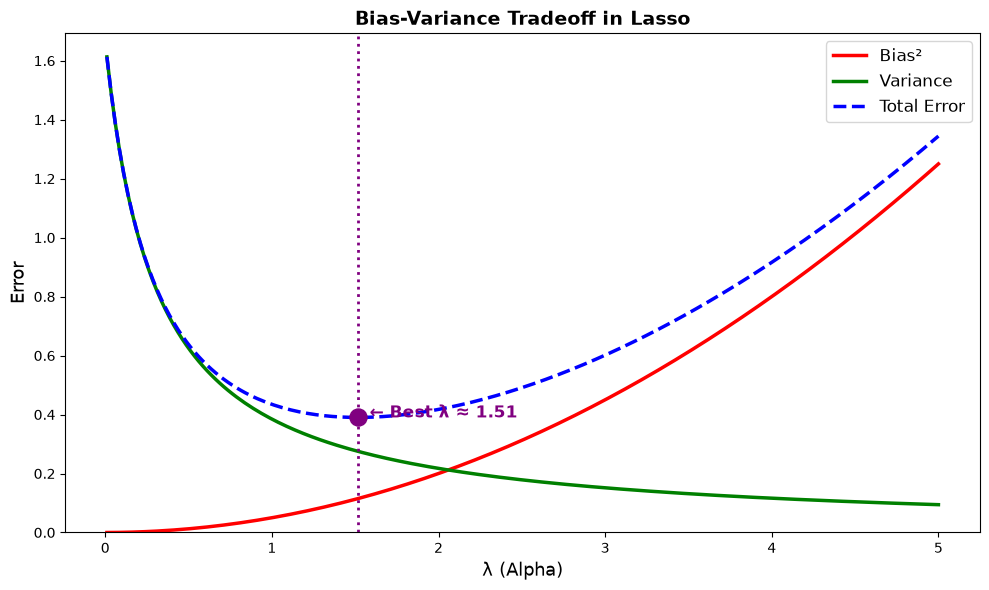

In [7]:
# Visualize the bias-variance tradeoff concept
fig, ax = plt.subplots(figsize=(10, 6))

lam = np.linspace(0.01, 5, 200)
bias_sq = 0.05 * lam**2
variance = 0.5 / (lam + 0.3)
total = bias_sq + variance

ax.plot(lam, bias_sq, 'r-', linewidth=2.5, label='Bias²')
ax.plot(lam, variance, 'g-', linewidth=2.5, label='Variance')
ax.plot(lam, total, 'b--', linewidth=2.5, label='Total Error')

opt_idx = np.argmin(total)
ax.axvline(x=lam[opt_idx], color='purple', linestyle=':', linewidth=2)
ax.scatter([lam[opt_idx]], [total[opt_idx]], color='purple', s=150, zorder=5)
ax.annotate(f'  ← Best λ ≈ {lam[opt_idx]:.2f}', xy=(lam[opt_idx], total[opt_idx]),
            fontsize=12, fontweight='bold', color='purple')

ax.set_xlabel('λ (Alpha)', fontsize=13)
ax.set_ylabel('Error', fontsize=13)
ax.set_title('Bias-Variance Tradeoff in Lasso', fontsize=14, fontweight='bold')
ax.legend(fontsize=12)
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()

### How to Choose λ in Practice?

Use **cross-validation**! sklearn provides `LassoCV` which automatically finds the best $\lambda$:

```python
from sklearn.linear_model import LassoCV
lasso_cv = LassoCV(cv=5)
lasso_cv.fit(X_train, y_train)
print(f'Best alpha: {lasso_cv.alpha_}')
```

---
## 9. Lasso — Code Implementation

### 9.1 Basic Lasso on Synthetic Data

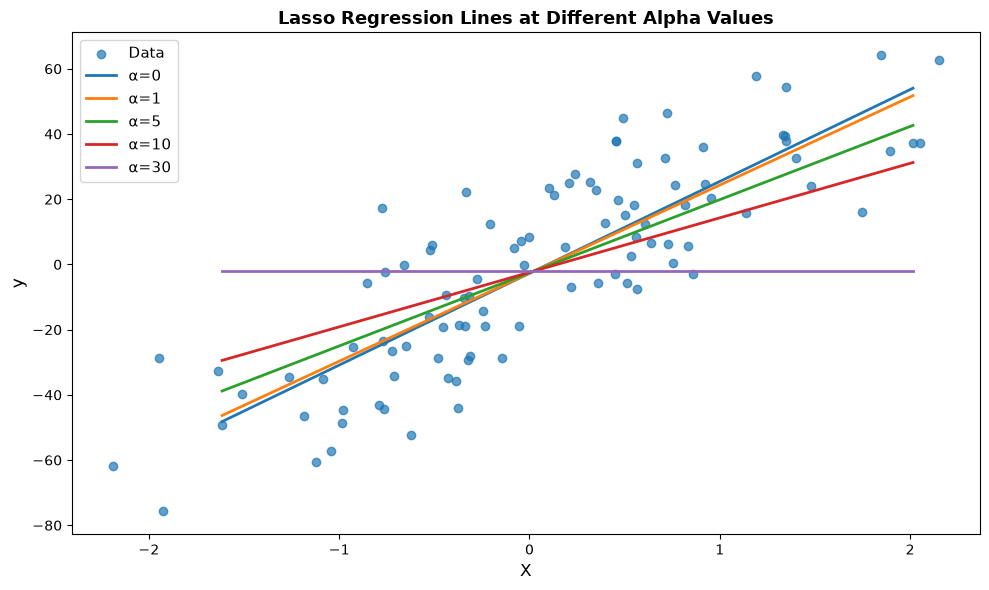

In [8]:
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression

# Generate synthetic data
X, y = make_regression(n_samples=100, n_features=1,
                       n_informative=1, n_targets=1, noise=20, random_state=13)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

plt.figure(figsize=(10, 6))
plt.scatter(X, y, alpha=0.7, label='Data')

# Fit with different alphas
for alpha in [0, 1, 5, 10, 30]:
    lasso = Lasso(alpha=alpha)
    lasso.fit(X_train, y_train)
    X_sorted = np.sort(X_test, axis=0)
    plt.plot(X_sorted, lasso.predict(X_sorted), label=f'α={alpha}', linewidth=2)

plt.xlabel('X', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title('Lasso Regression Lines at Different Alpha Values', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

**Observation:** As $\alpha$ increases, the regression line becomes **flatter** (slope → 0).
At very high $\alpha$, the model essentially predicts the mean of $y$.

### 9.2 Using LassoCV for Automatic Alpha Selection

In [9]:
from sklearn.linear_model import LassoCV

# Reload diabetes data
data = load_diabetes()
X_train, X_test, y_train, y_test = train_test_split(
    data.data, data.target, test_size=0.2, random_state=2
)

# LassoCV automatically picks the best alpha via cross-validation
lasso_cv = LassoCV(cv=5, random_state=42)
lasso_cv.fit(X_train, y_train)

print(f'Best Alpha: {lasso_cv.alpha_:.4f}')
print(f'R² Score:   {lasso_cv.score(X_test, y_test):.4f}')
print(f'\nNon-zero coefficients: {np.sum(lasso_cv.coef_ != 0)} / {len(lasso_cv.coef_)}')
print('\nCoefficients:')
for name, coef in zip(data.feature_names, lasso_cv.coef_):
    status = '✅' if coef != 0 else '❌ (eliminated)'
    print(f'  {name:>5s}: {coef:>10.2f}  {status}')

Best Alpha: 0.0541
R² Score:   0.4380

Non-zero coefficients: 7 / 10

Coefficients:
    age:      -0.00  ❌ (eliminated)
    sex:    -151.90  ✅
    bmi:     528.98  ✅
     bp:     311.72  ✅
     s1:    -128.44  ✅
     s2:      -0.00  ❌ (eliminated)
     s3:    -164.14  ✅
     s4:       0.00  ❌ (eliminated)
     s5:     577.88  ✅
     s6:      28.65  ✅


---
## 10. Elastic Net Regression

### What is Elastic Net?

$$\text{Elastic Net} = \text{Ridge} + \text{Lasso}$$

It combines **both** L1 and L2 penalties!

### Loss Function

$$\boxed{\mathcal{L}_{\text{ElasticNet}} = \sum_{i=1}^{n}(y_i - \hat{y}_i)^2 + a\|w\|_2^2 + b\|w\|_1}$$

where:
- $a$ = weight of the **Ridge** (L2) component
- $b$ = weight of the **Lasso** (L1) component
- $\lambda = a + b$ (total regularization strength)

### The `l1_ratio` Parameter (sklearn)

$$\text{l1\_ratio} = \frac{a}{a + b} = \frac{a}{\lambda}$$

So the formula becomes:

$$\boxed{\mathcal{L} = \sum(y_i - \hat{y}_i)^2 + \lambda\left[\underbrace{\text{l1\_ratio} \cdot \|w\|_1}_{\text{Lasso part}} + \underbrace{(1 - \text{l1\_ratio}) \cdot \|w\|_2^2}_{\text{Ridge part}}\right]}$$

| `l1_ratio` | Behavior |
|---|---|
| **0** | Pure **Ridge** regression |
| **0.5** | Equal mix of Ridge and Lasso |
| **1** | Pure **Lasso** regression |

### When to Use Elastic Net?

> ⚡ **Use Elastic Net when the input data has multicollinearity** (highly correlated features).

- Lasso alone tends to **arbitrarily pick one** correlated feature and drop the rest
- Elastic Net (with Ridge component) handles groups of correlated features better
- Adjust `l1_ratio` to balance Ridge vs Lasso effect

In [10]:
from sklearn.linear_model import ElasticNet

# Compare Lasso vs Elastic Net
print('='*60)
print(f'{"Method":^20s} | {"R²":^8s} | {"Non-zero coefs":^15s}')
print('='*60)

for name, model in [('Lasso (α=0.1)', Lasso(alpha=0.1)),
                     ('ElasticNet (0.5)', ElasticNet(alpha=0.1, l1_ratio=0.5)),
                     ('ElasticNet (0.9)', ElasticNet(alpha=0.1, l1_ratio=0.9)),
                     ('ElasticNet (0.1)', ElasticNet(alpha=0.1, l1_ratio=0.1))]:
    model.fit(X_train, y_train)
    r2 = r2_score(y_test, model.predict(X_test))
    nonzero = np.sum(model.coef_ != 0)
    print(f'{name:^20s} | {r2:^8.4f} | {nonzero:^15d}')

print('='*60)

       Method        |    R²    | Non-zero coefs 
   Lasso (α=0.1)     |  0.4335  |        7       
  ElasticNet (0.5)   |  0.0925  |       10       
  ElasticNet (0.9)   |  0.2702  |        9       
  ElasticNet (0.1)   |  0.0531  |       10       


---
## 11. Ridge vs Lasso vs Elastic Net — Comparison

| Feature | Ridge | Lasso | Elastic Net |
|---------|-------|-------|-------------|
| **Penalty** | $\lambda \sum w_j^2$ | $\lambda \sum \|w_j\|$ | $\lambda_1 \sum w_j^2 + \lambda_2 \sum \|w_j\|$ |
| **Norm** | L2 | L1 | L1 + L2 |
| **Coefficients → 0?** | ❌ Shrinks, never 0 | ✅ Can be exactly 0 | ✅ Can be exactly 0 |
| **Feature selection** | ❌ No | ✅ Yes | ✅ Yes |
| **Handles multicollinearity** | ✅ Yes | ⚠️ Picks one, drops rest | ✅ Yes |
| **Best for** | Many small features | Few important features | Multicollinear data |
| **Where λ appears (slope)** | Denominator | Numerator | Both |
| **Derivative of penalty** | Smooth ($2w_j$) | Non-smooth ($\text{sign}(w_j)$) | Mix |

---
## 12. Important Questions for Revision

### ❓ Q1: Why does Lasso create sparsity but Ridge does not?

<details>
<summary><b>Click to reveal answer</b></summary>

In **Ridge**, $\lambda$ appears in the **denominator** of the slope formula:
$$m = \frac{\sum(y_i-\bar{y})(x_i-\bar{x})}{\sum(x_i-\bar{x})^2 + \lambda}$$
As $\lambda$ increases, the denominator grows → $m$ **approaches 0 but never reaches it**.

In **Lasso**, $\lambda$ appears in the **numerator**:
$$m = \frac{\sum(y_i-\bar{y})(x_i-\bar{x}) - \lambda}{\sum(x_i-\bar{x})^2}$$
When $\lambda$ equals or exceeds the numerator value, $m$ becomes **exactly 0**. This is **sparsity**!

</details>

### ❓ Q2: What happens when α = 0 in Lasso?

<details>
<summary><b>Click to reveal answer</b></summary>

Lasso becomes **normal linear regression** (OLS). There is no penalty, so all coefficients are unrestricted.

$$\mathcal{L} = \text{MSE} + 0 \cdot \|w\|_1 = \text{MSE}$$

</details>

### ❓ Q3: How does Lasso perform feature selection?

<details>
<summary><b>Click to reveal answer</b></summary>

As $\lambda$ increases, Lasso progressively shrinks coefficients. The **less important** features (smaller contributions) are driven to **exactly zero first**. Only the most important features retain non-zero coefficients. This is **automatic feature selection** — no manual intervention needed!

</details>

### ❓ Q4: What is the effect of increasing alpha on Bias and Variance?

<details>
<summary><b>Click to reveal answer</b></summary>

- **Increasing $\lambda$:** Overfitting ↓, Bias ↑, Variance ↓
- **Decreasing $\lambda$:** Overfitting ↑, Bias ↓, Variance ↑
- We choose $\lambda$ in the **region where total error is minimized** (the sweet spot).
- In practice, use **cross-validation** (`LassoCV`).

</details>

### ❓ Q5: Why use Elastic Net instead of just Lasso?

<details>
<summary><b>Click to reveal answer</b></summary>

When features are **multicollinear** (highly correlated), Lasso tends to **arbitrarily pick one** feature from a correlated group and drop the rest. Elastic Net, by adding the Ridge (L2) penalty, handles groups of correlated features better — it tends to keep or drop them **together**.

</details>

### ❓ Q6: What is `l1_ratio` in ElasticNet?

<details>
<summary><b>Click to reveal answer</b></summary>

- $\text{l1\_ratio} = \dfrac{a}{a + b}$ where $a$ is the L1 (Lasso) weight and $b$ is the L2 (Ridge) weight.
- `l1_ratio = 0` → pure **Ridge**
- `l1_ratio = 1` → pure **Lasso**
- `l1_ratio = 0.5` → **equal mix**

</details>

### ❓ Q7: Why are higher coefficients affected more by Lasso?

<details>
<summary><b>Click to reveal answer</b></summary>

Lasso subtracts a **constant** $\lambda$ from the numerator. This constant $\lambda$ is the same for all features. So features with **smaller numerator values** (less important features) hit zero first, while features with **larger numerator values** (more important features) survive longer. In the coefficient path plot, you can see features disappearing one by one as $\lambda$ grows.

</details>

### ❓ Q8: Write the loss functions for Ridge, Lasso, and Elastic Net.

<details>
<summary><b>Click to reveal answer</b></summary>

$$\mathcal{L}_{\text{Ridge}} = \sum_{i=1}^{n}(y_i - \hat{y}_i)^2 + \lambda \sum_{j=1}^{p} w_j^2$$

$$\mathcal{L}_{\text{Lasso}} = \sum_{i=1}^{n}(y_i - \hat{y}_i)^2 + \lambda \sum_{j=1}^{p} |w_j|$$

$$\mathcal{L}_{\text{ElasticNet}} = \sum_{i=1}^{n}(y_i - \hat{y}_i)^2 + \lambda\left[\alpha \sum_{j=1}^{p} |w_j| + (1-\alpha) \sum_{j=1}^{p} w_j^2\right]$$

</details>

---
## 13. Quick Revision Cheat Sheet

### LASSO = L1 Regularization
$$\mathcal{L} = \text{MSE} + \lambda(|w_1| + |w_2| + \cdots + |w_n|)$$
- ✅ Can make coefficients **EXACTLY ZERO** → Feature Selection
- $\lambda$ in **NUMERATOR** of slope formula
- Higher $\lambda$ → more coefficients = 0 → simpler model
- $\lambda = 0$ → normal linear regression

### RIDGE = L2 Regularization
$$\mathcal{L} = \text{MSE} + \lambda(w_1^2 + w_2^2 + \cdots + w_n^2)$$
- ❌ Coefficients **SHRINK but NEVER = 0**
- $\lambda$ in **DENOMINATOR** of slope formula
- Good when all features matter

### ELASTIC NET = L1 + L2
$$\mathcal{L} = \text{MSE} + \lambda\left[\alpha\|w\|_1 + (1-\alpha)\|w\|_2^2\right]$$
- Use when data has **MULTICOLLINEARITY**
- `l1_ratio=0` → Ridge, `l1_ratio=1` → Lasso

### BIAS-VARIANCE
- $\lambda \uparrow$ → Bias ↑, Variance ↓, Overfitting ↓
- $\lambda \downarrow$ → Bias ↓, Variance ↑, Overfitting ↑
- Choose $\lambda$ at the **SWEET SPOT** (use cross-validation)

---

> **"Why does Lasso create sparsity?"**
>
> Because $\lambda$ appears in the **numerator** (not denominator like Ridge),
> so when $\lambda$ is large enough, the numerator becomes 0,
> making the coefficient **exactly 0**.
> This is the fundamental reason for feature selection in Lasso!